<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/Deep_Learning_TP2_Cohorte_24_2B2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 24 - 2do bimestre 2026

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## Data Load

In [24]:
# Librerias
import gdown
import pandas as pd




custom_palette = {'<=50K': '#ff9999', '>50K': '#add8e6'}

In [25]:
# Enlace a la carpeta de Google Drive
folder_url = 'https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln'

# Descargar la carpeta completa en un directorio específico llamado 'dataset'
print("Descargando archivos desde Google Drive...")
gdown.download_folder(folder_url, output='dataset', quiet=True, use_cookies=False)

# Cargar los archivos directamente en las variables train y test
train = pd.read_csv('dataset/adult_train.csv')
test = pd.read_csv('dataset/adult_val.csv')

Descargando archivos desde Google Drive...


## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [26]:
# Train

print(train.info())
display(train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   education       30162 non-null  object
 3   marital-status  30162 non-null  object
 4   occupation      30162 non-null  object
 5   relationship    30162 non-null  object
 6   race            30162 non-null  object
 7   sex             30162 non-null  object
 8   capital-gain    30162 non-null  int64 
 9   capital-loss    30162 non-null  int64 
 10  hours-per-week  30162 non-null  int64 
 11  skill-profile   30162 non-null  object
 12  native-country  30162 non-null  object
 13  income          30162 non-null  object
dtypes: int64(4), object(10)
memory usage: 3.2+ MB
None


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


In [27]:
# Test

print(test.info())
display(test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15060 entries, 0 to 15059
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             15060 non-null  int64 
 1   workclass       15060 non-null  object
 2   education       15060 non-null  object
 3   marital-status  15060 non-null  object
 4   occupation      15060 non-null  object
 5   relationship    15060 non-null  object
 6   race            15060 non-null  object
 7   sex             15060 non-null  object
 8   capital-gain    15060 non-null  int64 
 9   capital-loss    15060 non-null  int64 
 10  hours-per-week  15060 non-null  int64 
 11  skill-profile   15060 non-null  object
 12  native-country  15060 non-null  object
 13  income          15060 non-null  object
dtypes: int64(4), object(10)
memory usage: 1.6+ MB
None


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,logistics_warehouse_basic,United-States,<=50K
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,security_patrol_basic,United-States,<=50K
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,trade_cnc_operation,United-States,>50K
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,transport_commercial_driving,United-States,>50K
4,34,Private,10th,Never-married,Other-service,Not-in-family,White,Male,0,0,30,personal_care_assistance,United-States,<=50K


- 30K registros en Train y 15K resitros en Test
- No hay nulos

### Análisis de la variable Target (Income)

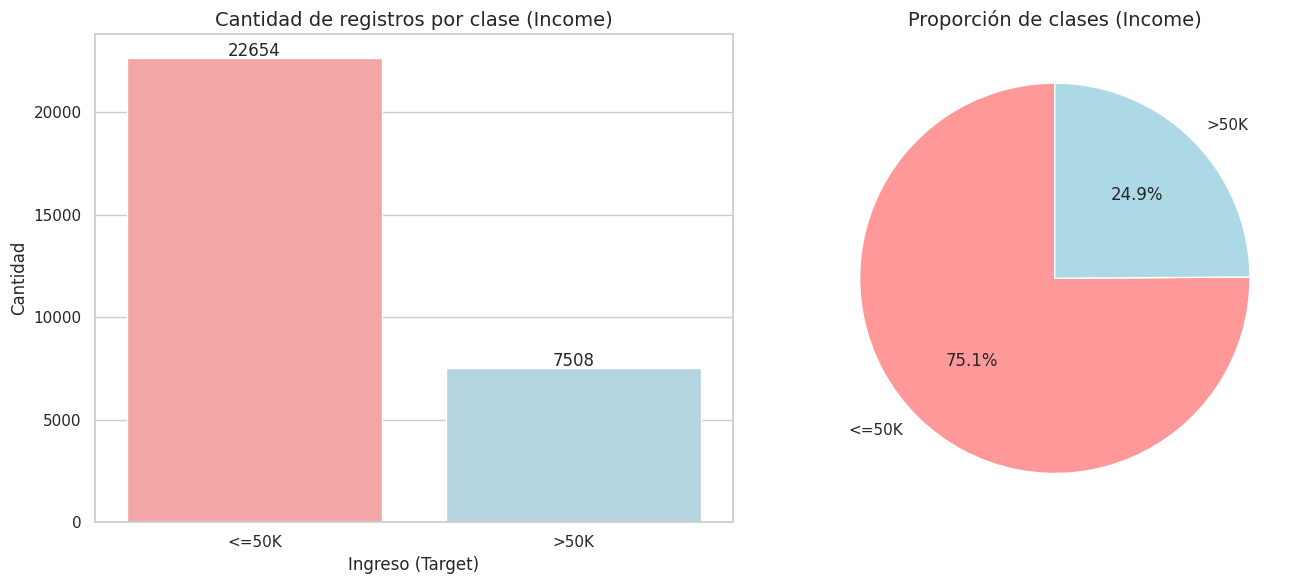


Conteo exacto de la variable 'income':


,count
income,
<=50K,22654
>50K,7508



Proporción de la variable 'income':


,proportion
income,
<=50K,75.107751
>50K,24.892249


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de barras (Countplot)
# Se agrega hue='income' y legend=False para evitar el FutureWarning de Seaborn
sns.countplot(data=train, x='income', ax=axes[0], hue='income', palette=custom_palette, legend=False)
axes[0].set_title('Cantidad de registros por clase (Income)', fontsize=14)
axes[0].set_xlabel('Ingreso (Target)', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)

# Agregar los valores exactos sobre las barras
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Gráfico de torta (Pie chart)
income_counts = train['income'].value_counts()
# Mapeamos los colores desde custom_palette respetando el orden del índice
pie_colors = [custom_palette[val] for val in income_counts.index]
axes[1].pie(income_counts, labels=income_counts.index, autopct='%1.1f%%', startangle=90, colors=pie_colors)
axes[1].set_title('Proporción de clases (Income)', fontsize=14)

plt.tight_layout()
plt.show()

# Mostrar el conteo exacto y las proporciones en texto
print("\nConteo exacto de la variable 'income':")
display(train['income'].value_counts())

print("\nProporción de la variable 'income':")
display(train['income'].value_counts(normalize=True) * 100)

- Defino la Clase Positiva como >50K
- Un poco desbalanceada (1/4)

### Age

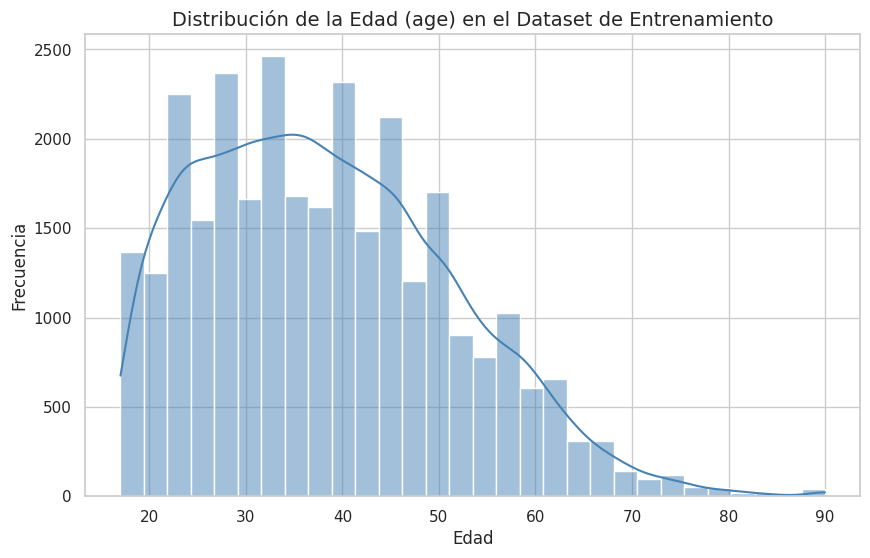


Estadísticas descriptivas de la variable 'age':


,age
count,30162.000000
mean,38.437902
std,13.134665
min,17.000000
25%,28.000000
50%,37.000000
75%,47.000000
max,90.000000


In [29]:
# Age

import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear el histograma para la variable 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=train, x='age', bins=30, kde=True, color='steelblue')
plt.title('Distribución de la Edad (age) en el Dataset de Entrenamiento', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

# Mostrar estadísticas descriptivas de la variable 'age'
print("\nEstadísticas descriptivas de la variable 'age':")
display(train['age'].describe())

- Media de 38y
- Talvez se pueda capear los valores maximos?

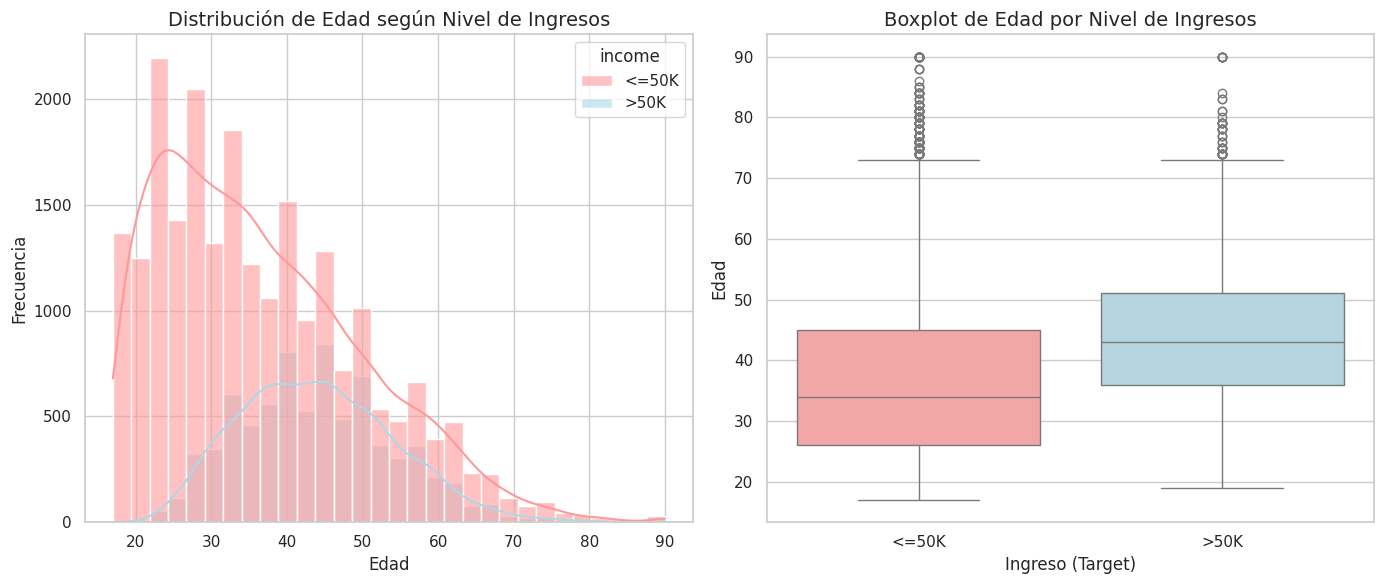

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Histograma superpuesto por clase (Income)
sns.histplot(data=train, x='age', hue='income', bins=30, kde=True, ax=axes[0], palette=custom_palette, alpha=0.6)
axes[0].set_title('Distribución de Edad según Nivel de Ingresos', fontsize=14)
axes[0].set_xlabel('Edad', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# 2. Boxplot de Edad por clase (Income)
# Se asigna hue='income' y legend=False para evitar warnings de seaborn
sns.boxplot(data=train, x='income', y='age', hue='income', ax=axes[1], palette=custom_palette, legend=False)
axes[1].set_title('Boxplot de Edad por Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Ingreso (Target)', fontsize=12)
axes[1].set_ylabel('Edad', fontsize=12)

plt.tight_layout()
plt.show()

- La Clase Positiva parecia ser 10 años mayor en promedio
- Tambien en ella la edad se distribuye normalmente casi de manera perfecta

### Workclass
Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

La cardinalidad de 'workclass' es: 7
Valores únicos:
workclass
Private             22286
Self-emp-not-inc     2499
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Name: count, dtype: int64



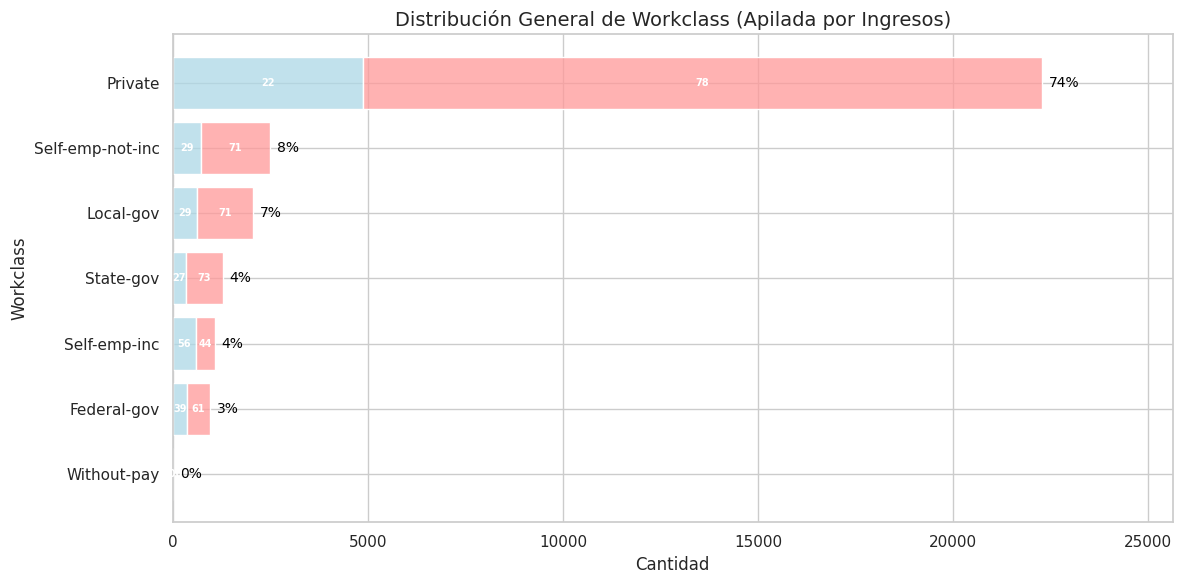

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Chequeo de seguridad por si el kernel se reinició
if 'train' not in globals():
    train = pd.read_csv('dataset/adult_train.csv')
if 'custom_palette' not in globals():
    custom_palette = {'<=50K': '#ff9999', '>50K': '#add8e6'}

# Analizar cardinalidad
cardinalidad_workclass = train['workclass'].nunique()
valores_unicos_workclass = train['workclass'].unique()
conteo_workclass = train['workclass'].value_counts()

print(f"La cardinalidad de 'workclass' es: {cardinalidad_workclass}")
print(f"Valores únicos:\n{conteo_workclass}\n")

# Configurar la figura para un solo gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Convertimos a categórica temporalmente para asegurar el orden en histplot
train['workclass'] = pd.Categorical(train['workclass'], categories=conteo_workclass.index, ordered=True)

# 1. Distribución general de Workclass (Apilada por Target)
sns.histplot(data=train, y='workclass', hue='income', multiple='stack',
             ax=ax, palette=custom_palette, legend=False, shrink=0.8)
ax.set_title('Distribución General de Workclass (Apilada por Ingresos)', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Workclass', fontsize=12)

# Extender el límite x para que entren los porcentajes afuera
ax.set_xlim(0, conteo_workclass.max() * 1.15)

total_workclass = len(train)

# Agregar porcentajes del total al final de las barras apiladas (Afuera)
for i, (val, width) in enumerate(conteo_workclass.items()):
    if width > 0:
        percentage = f'{100 * width / total_workclass:.0f}%'
        # En gráficos categóricos, la posición 'y' coincide con el índice 'i'
        # Colocar afuera por defecto, adentro si no hay suficiente espacio
        if width > (0.9 * ax.get_xlim()[1]):
            ax.annotate(percentage, (width, i),
                             ha='right', va='center', xytext=(-5, 0), textcoords='offset points',
                             color='white', fontweight='bold', fontsize=10)
        else:
            ax.annotate(percentage, (width, i),
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                             color='black', fontsize=10)

# Agregar porcentajes internos relativos a cada barra (suman 100% por categoría)
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center)) # Índice de la categoría en el eje Y
        total_bar = conteo_workclass.iloc[idx]
        pct = 100 * w / total_bar

        # Mostrar solo si el segmento es > 4% para que haya lugar
        if pct > 4:
            # Sin símbolo de porcentaje y sin decimales (fontsize=7)
            ax.annotate(f'{pct:.0f}',
                        (p.get_x() + w / 2, y_center),
                        ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Revertimos a tipo object para no afectar celdas posteriores
train['workclass'] = train['workclass'].astype(object)

plt.tight_layout()
plt.show()

- Carnilaidad de 7. Probar one-hot y embeddings
- La gran mayoría de las personas trabajan en el sector privado (`Private`).
- Que hacemos con "Without-pay"?
- Proporcionalmente, los trabajadores independientes registrados y los federales, son los que tienen la mayor tasa de buenos

### Education
Nivel educativo alcanzado del individuo.

La cardinalidad de 'education' es: 16
Diccionario de ordenamiento:
{'Preschool': '01-Preschool', '1st-4th': '02-1st-4th', '5th-6th': '03-5th-6th', '7th-8th': '04-7th-8th', '9th': '05-9th', '10th': '06-10th', '11th': '07-11th', '12th': '08-12th', 'HS-grad': '09-HS-grad', 'Some-college': '10-Some-college', 'Assoc-voc': '11-Assoc-voc', 'Assoc-acdm': '12-Assoc-acdm', 'Bachelors': '13-Bachelors', 'Masters': '14-Masters', 'Prof-school': '15-Prof-school', 'Doctorate': '16-Doctorate'}



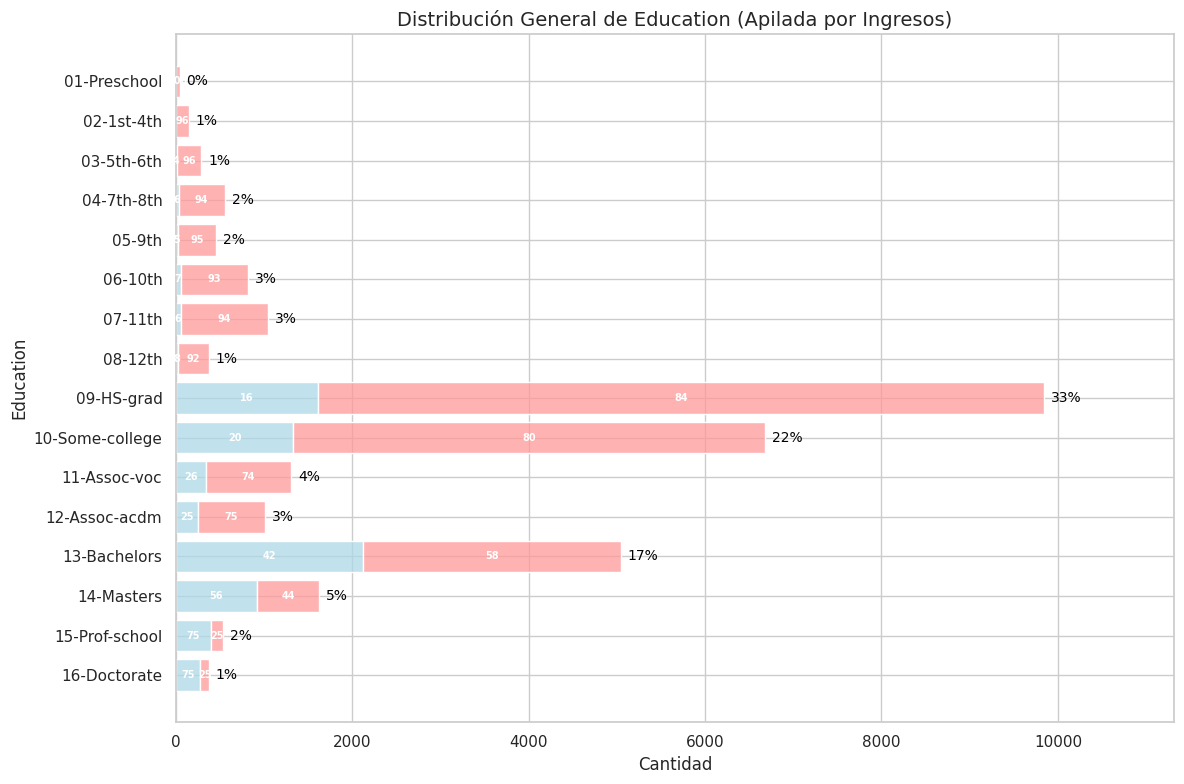

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Chequeo por si se reinicia el kernel
if 'train' not in globals():
    train = pd.read_csv('dataset/adult_train.csv')
if 'custom_palette' not in globals():
    custom_palette = {'<=50K': '#ff9999', '>50K': '#add8e6'}

# Definir el orden lógico de la educación de menor a mayor
education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
    'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters',
    'Prof-school', 'Doctorate'
]

# Crear diccionario agregando el número de dos dígitos seguido de un guión
education_mapping = {edu: f"{i+1:02d}-{edu}" for i, edu in enumerate(education_order)}

# Aplicar el mapeo si no ha sido aplicado aún (para no duplicar si se corre la celda varias veces)
if not str(train['education'].iloc[0]).startswith(('0', '1')):
    train['education'] = train['education'].map(education_mapping)

# Obtener la lista ordenada alfabéticamente (que ahora coincide con el orden lógico)
order_edu = sorted(train['education'].dropna().unique())

# Analizar cardinalidad y conteo (ordenado lógicamente para alinear con el gráfico)
cardinalidad_education = train['education'].nunique()
conteo_education = train['education'].value_counts().reindex(order_edu)

print(f"La cardinalidad de 'education' es: {cardinalidad_education}")
print(f"Diccionario de ordenamiento:\n{education_mapping}\n")

# Configurar la figura para un solo gráfico
fig, ax = plt.subplots(figsize=(12, 8))

# Convertimos a categórica temporalmente para asegurar el orden en histplot
train['education'] = pd.Categorical(train['education'], categories=order_edu, ordered=True)

# 1. Distribución general de Education (Apilada por Target)
sns.histplot(data=train, y='education', hue='income', multiple='stack',
             ax=ax, palette=custom_palette, legend=False, shrink=0.8)
ax.set_title('Distribución General de Education (Apilada por Ingresos)', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Education', fontsize=12)

# Extender el límite x para que entren los porcentajes afuera
ax.set_xlim(0, conteo_education.max() * 1.15)

total_records = len(train)

# Agregar porcentajes del total al final de las barras apiladas (Afuera)
for i, (val, width) in enumerate(conteo_education.items()):
    if width > 0:
        percentage = f'{100 * width / total_records:.0f}%'
        # En gráficos categóricos, la posición 'y' coincide con el índice 'i'
        if width > (0.9 * ax.get_xlim()[1]):
            ax.annotate(percentage, (width, i),
                             ha='right', va='center', xytext=(-5, 0), textcoords='offset points',
                             color='white', fontweight='bold', fontsize=10)
        else:
            ax.annotate(percentage, (width, i),
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                             color='black', fontsize=10)

# Agregar porcentajes internos relativos a cada barra (suman 100% por categoría)
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center)) # Índice de la categoría en el eje Y
        total_bar = conteo_education.iloc[idx]
        pct = 100 * w / total_bar

        # Mostrar solo si el segmento es > 4% para que haya lugar
        if pct > 4:
            # Sin símbolo de porcentaje y sin decimales
            ax.annotate(f'{pct:.0f}',
                        (p.get_x() + w / 2, y_center),
                        ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Revertimos a tipo object para no afectar celdas posteriores
train['education'] = train['education'].astype(object)

plt.tight_layout()
plt.show()

- Cardinalidad de 16, sera mucho para ordinal? o embeddings? Probar ambas
- A medida que aumenta el nivel educativo (por ejemplo, de `Bachelors` a `Masters` y `Doctorate`), se puede observar una mayor proporción de personas que ganan más de 50K.

### Marital-status
Estado civil del individuo.

La cardinalidad de 'marital-status' es: 7
Valores únicos:
marital-status
Married-civ-spouse       14065
Never-married             9726
Divorced                  4214
Separated                  939
Widowed                    827
Married-spouse-absent      370
Married-AF-spouse           21
Name: count, dtype: int64



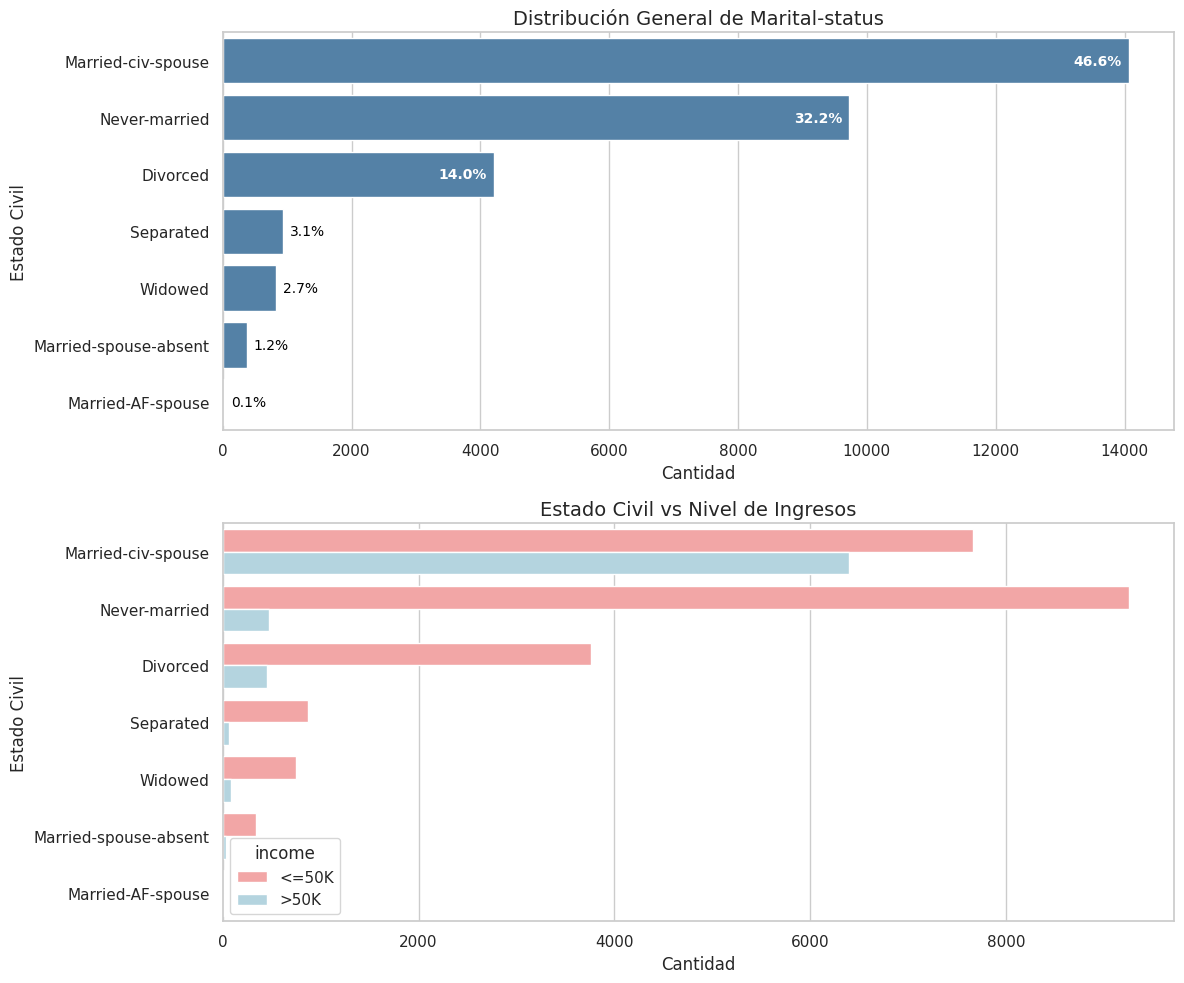

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analizar cardinalidad
cardinalidad_marital = train['marital-status'].nunique()
valores_unicos_marital = train['marital-status'].unique()
conteo_marital = train['marital-status'].value_counts()

print(f"La cardinalidad de 'marital-status' es: {cardinalidad_marital}")
print(f"Valores únicos:\n{conteo_marital}\n")

# Configurar la figura
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. Distribución general de Marital-status
sns.countplot(data=train, y='marital-status', ax=axes[0], order=conteo_marital.index, color='steelblue')
axes[0].set_title('Distribución General de Marital-status', fontsize=14)
axes[0].set_xlabel('Cantidad', fontsize=12)
axes[0].set_ylabel('Estado Civil', fontsize=12)

# Agregar porcentajes adentro/junto a las barras
total_records = len(train)
for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        percentage = f'{100 * width / total_records:.1f}%'
        if width < (0.04 * total_records):
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points', color='black', fontsize=10)
        else:
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='right', va='center', xytext=(-5, 0), textcoords='offset points', color='white', fontweight='bold', fontsize=10)

# 2. Marital-status vs Income
sns.countplot(data=train, y='marital-status', hue='income', ax=axes[1], order=conteo_marital.index, palette=custom_palette)
axes[1].set_title('Estado Civil vs Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Cantidad', fontsize=12)
axes[1].set_ylabel('Estado Civil', fontsize=12)

plt.tight_layout()
plt.show()

- Cardinalidad de 7, pensar disintas opciones
- Billetera Mata Galan:  Las personas casadas (`Married-civ-spouse`) tienen una proporción significativamente mayor de ingresos >50K en comparación con el resto de las categorías.

### Occupation
Tipo de ocupación o área laboral.

La cardinalidad de 'occupation' es: 14
Valores únicos:
occupation
Prof-specialty       4038
Craft-repair         4030
Exec-managerial      3992
Adm-clerical         3721
Sales                3584
Other-service        3212
Machine-op-inspct    1966
Transport-moving     1572
Handlers-cleaners    1350
Farming-fishing       989
Tech-support          912
Protective-serv       644
Priv-house-serv       143
Armed-Forces            9
Name: count, dtype: int64



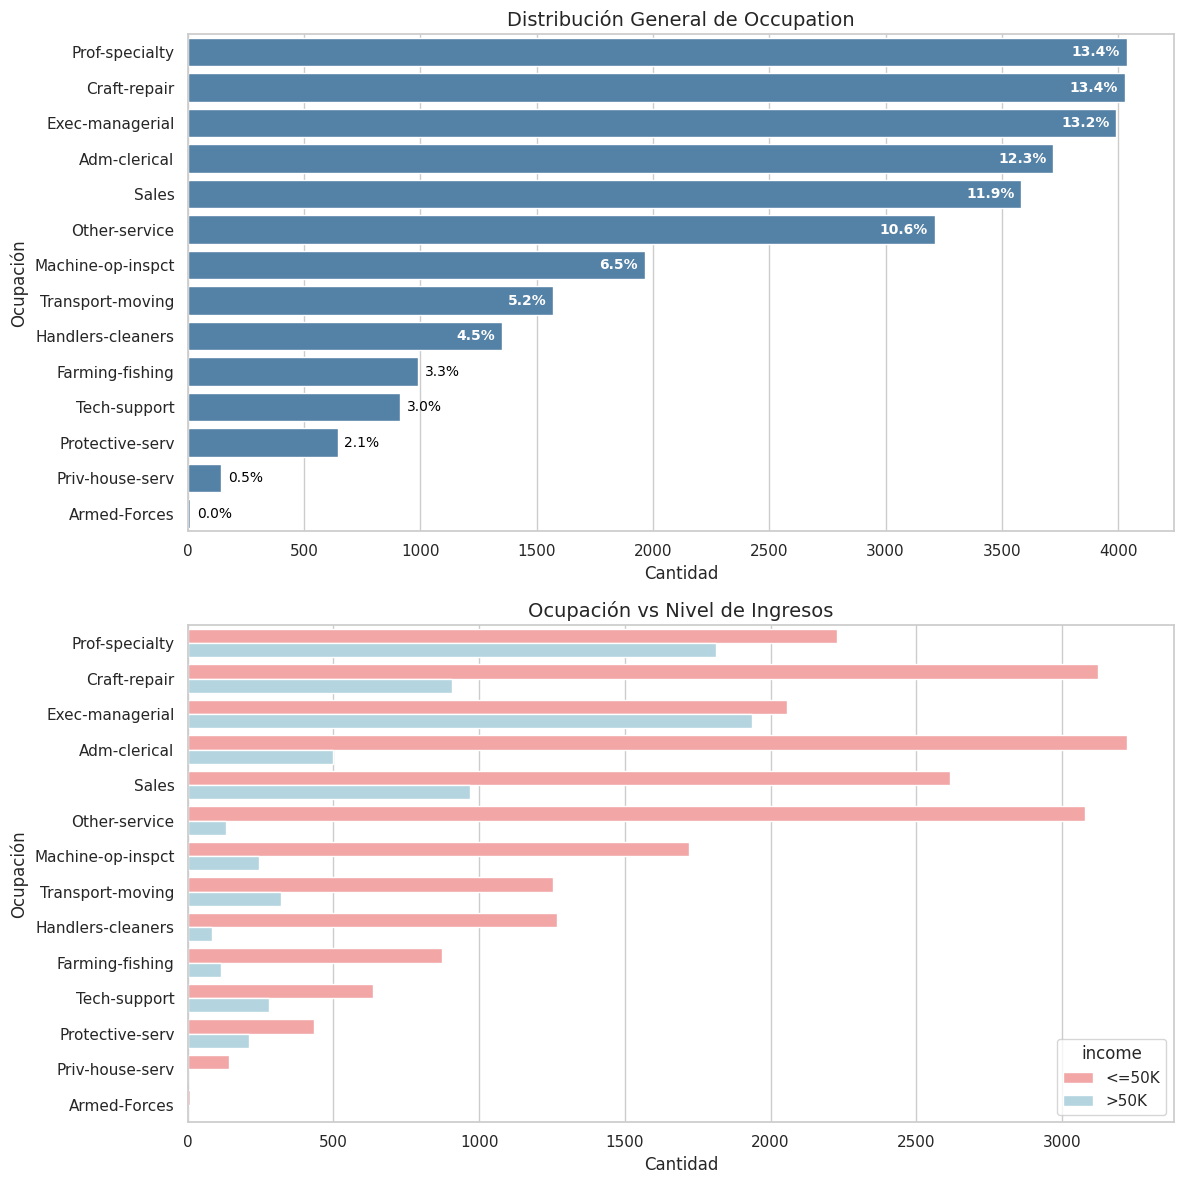

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analizar cardinalidad
cardinalidad_occupation = train['occupation'].nunique()
valores_unicos_occupation = train['occupation'].unique()
conteo_occupation = train['occupation'].value_counts()

print(f"La cardinalidad de 'occupation' es: {cardinalidad_occupation}")
print(f"Valores únicos:\n{conteo_occupation}\n")

# Configurar la figura
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# 1. Distribución general de Occupation
sns.countplot(data=train, y='occupation', ax=axes[0], order=conteo_occupation.index, color='steelblue')
axes[0].set_title('Distribución General de Occupation', fontsize=14)
axes[0].set_xlabel('Cantidad', fontsize=12)
axes[0].set_ylabel('Ocupación', fontsize=12)

# Agregar porcentajes adentro/junto a las barras
total_records = len(train)
for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        percentage = f'{100 * width / total_records:.1f}%'
        if width < (0.04 * total_records):
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points', color='black', fontsize=10)
        else:
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='right', va='center', xytext=(-5, 0), textcoords='offset points', color='white', fontweight='bold', fontsize=10)

# 2. Occupation vs Income
sns.countplot(data=train, y='occupation', hue='income', ax=axes[1], order=conteo_occupation.index, palette=custom_palette)
axes[1].set_title('Ocupación vs Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Cantidad', fontsize=12)
axes[1].set_ylabel('Ocupación', fontsize=12)

plt.tight_layout()
plt.show()

- Cardinalidad de 14, Embeddings

### Relationship
Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

La cardinalidad de 'relationship' es: 6
Valores únicos:
relationship
Husband           12463
Not-in-family      7726
Own-child          4466
Unmarried          3212
Wife               1406
Other-relative      889
Name: count, dtype: int64



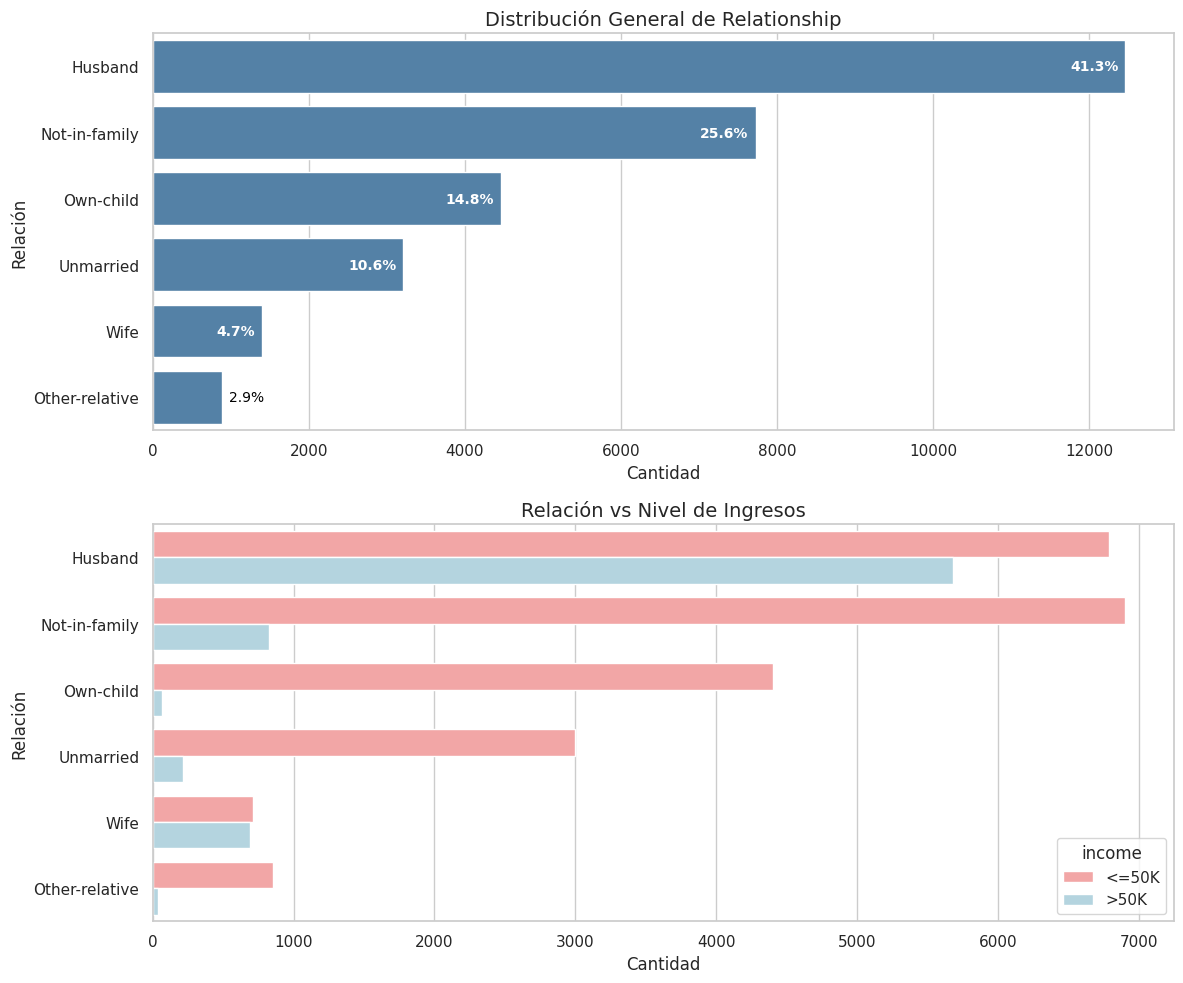

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analizar cardinalidad
cardinalidad_relationship = train['relationship'].nunique()
valores_unicos_relationship = train['relationship'].unique()
conteo_relationship = train['relationship'].value_counts()

print(f"La cardinalidad de 'relationship' es: {cardinalidad_relationship}")
print(f"Valores únicos:\n{conteo_relationship}\n")

# Configurar la figura
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. Distribución general de Relationship
sns.countplot(data=train, y='relationship', ax=axes[0], order=conteo_relationship.index, color='steelblue')
axes[0].set_title('Distribución General de Relationship', fontsize=14)
axes[0].set_xlabel('Cantidad', fontsize=12)
axes[0].set_ylabel('Relación', fontsize=12)

# Agregar porcentajes adentro/junto a las barras
total_records = len(train)
for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        percentage = f'{100 * width / total_records:.1f}%'
        if width < (0.04 * total_records):
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points', color='black', fontsize=10)
        else:
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='right', va='center', xytext=(-5, 0), textcoords='offset points', color='white', fontweight='bold', fontsize=10)

# 2. Relationship vs Income
sns.countplot(data=train, y='relationship', hue='income', ax=axes[1], order=conteo_relationship.index, palette=custom_palette)
axes[1].set_title('Relación vs Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Cantidad', fontsize=12)
axes[1].set_ylabel('Relación', fontsize=12)

plt.tight_layout()
plt.show()

- La cardinalidad de `relationship` es 6, por lo que **no se considera de alta cardinalidad** según el TP (<10). Una codificación One-Hot será adecuada.
- La mayoría de los individuos se catalogan como `Husband` o `Not-in-family`.
- Como era de esperarse tras analizar el estado civil, los roles familiares de `Husband` y `Wife` concentran la mayor proporción de ingresos >50K.

### Race
Autoidentificación racial del individuo.

La cardinalidad de 'race' es: 5
Valores únicos:
race
White                 25933
Black                  2817
Asian-Pac-Islander      895
Amer-Indian-Eskimo      286
Other                   231
Name: count, dtype: int64



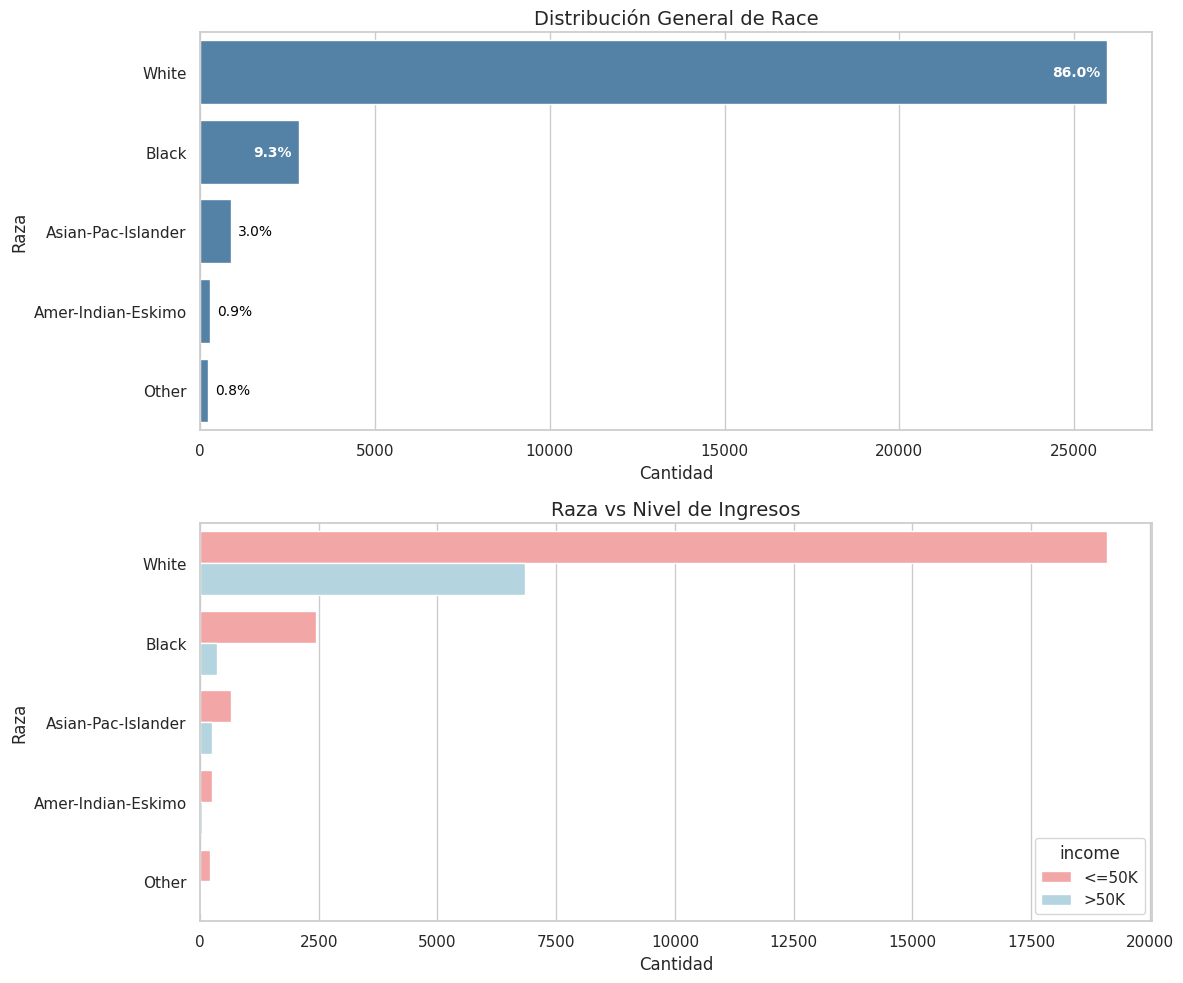

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analizar cardinalidad
cardinalidad_race = train['race'].nunique()
valores_unicos_race = train['race'].unique()
conteo_race = train['race'].value_counts()

print(f"La cardinalidad de 'race' es: {cardinalidad_race}")
print(f"Valores únicos:\n{conteo_race}\n")

# Configurar la figura
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. Distribución general de Race
sns.countplot(data=train, y='race', ax=axes[0], order=conteo_race.index, color='steelblue')
axes[0].set_title('Distribución General de Race', fontsize=14)
axes[0].set_xlabel('Cantidad', fontsize=12)
axes[0].set_ylabel('Raza', fontsize=12)

# Agregar porcentajes adentro/junto a las barras
total_records = len(train)
for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        percentage = f'{100 * width / total_records:.1f}%'
        if width < (0.04 * total_records):
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points', color='black', fontsize=10)
        else:
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='right', va='center', xytext=(-5, 0), textcoords='offset points', color='white', fontweight='bold', fontsize=10)

# 2. Race vs Income
sns.countplot(data=train, y='race', hue='income', ax=axes[1], order=conteo_race.index, palette=custom_palette)
axes[1].set_title('Raza vs Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Cantidad', fontsize=12)
axes[1].set_ylabel('Raza', fontsize=12)

plt.tight_layout()
plt.show()

- Cardinalidad de 6
- Agrupar por Otros?

### Sex
Sexo biológico del individuo (masculino o femenino).

La cardinalidad de 'sex' es: 2
Valores únicos:
sex
Male      20380
Female     9782
Name: count, dtype: int64



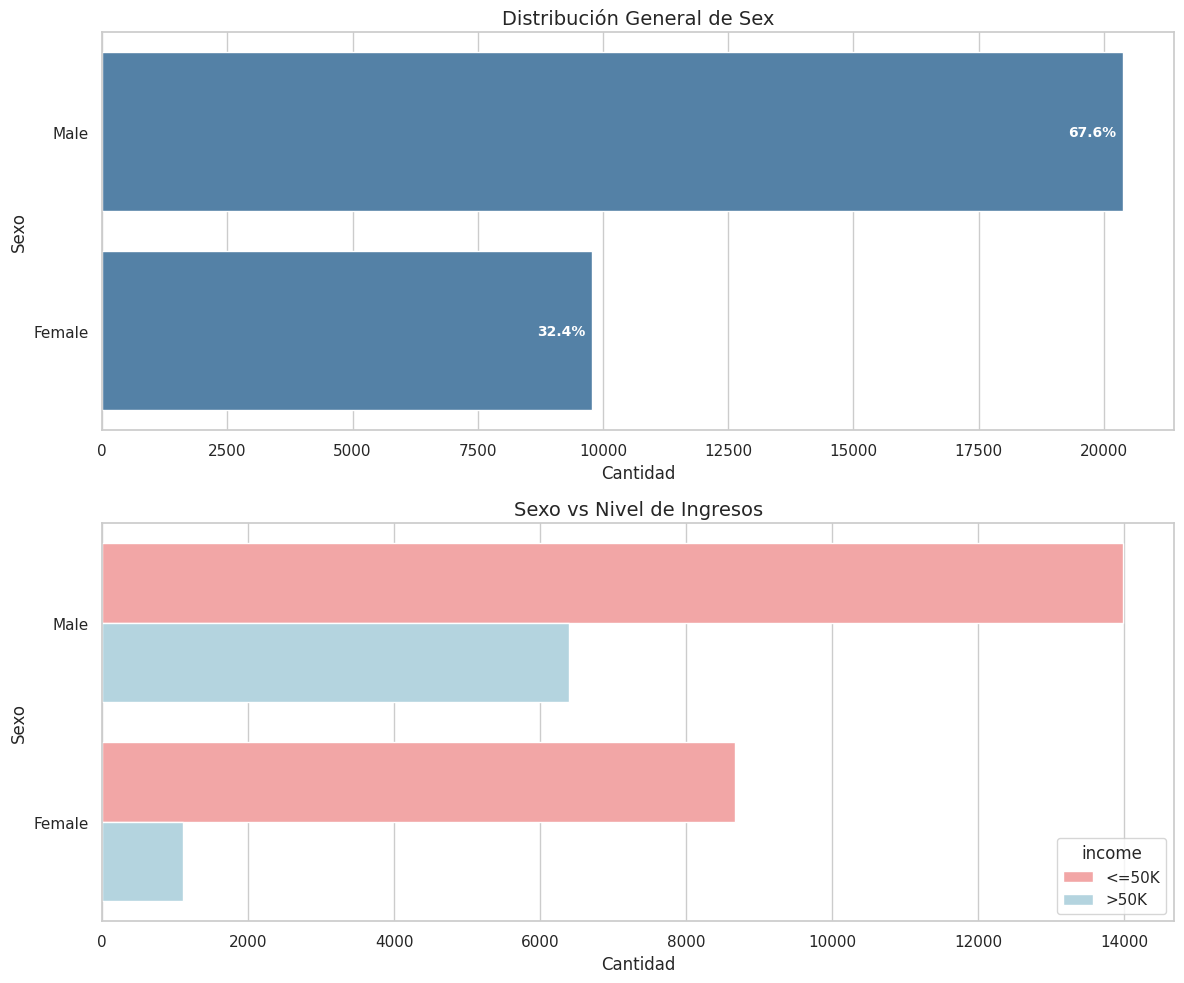

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analizar cardinalidad
cardinalidad_sex = train['sex'].nunique()
valores_unicos_sex = train['sex'].unique()
conteo_sex = train['sex'].value_counts()

print(f"La cardinalidad de 'sex' es: {cardinalidad_sex}")
print(f"Valores únicos:\n{conteo_sex}\n")

# Configurar la figura
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. Distribución general de Sex
sns.countplot(data=train, y='sex', ax=axes[0], order=conteo_sex.index, color='steelblue')
axes[0].set_title('Distribución General de Sex', fontsize=14)
axes[0].set_xlabel('Cantidad', fontsize=12)
axes[0].set_ylabel('Sexo', fontsize=12)

# Agregar porcentajes adentro/junto a las barras
total_records = len(train)
for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        percentage = f'{100 * width / total_records:.1f}%'
        if width < (0.04 * total_records):
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points', color='black', fontsize=10)
        else:
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='right', va='center', xytext=(-5, 0), textcoords='offset points', color='white', fontweight='bold', fontsize=10)

# 2. Sex vs Income
sns.countplot(data=train, y='sex', hue='income', ax=axes[1], order=conteo_sex.index, palette=custom_palette)
axes[1].set_title('Sexo vs Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Cantidad', fontsize=12)
axes[1].set_ylabel('Sexo', fontsize=12)

plt.tight_layout()
plt.show()

- Booleana o One-Hot? Hay realmente diferencias?

### Skill-profile
Habilidad principal o conocimiento técnico adquirido que podría aplicar en el trabajo.

La cardinalidad de 'skill-profile' es: 80
Top 15 valores únicos:
skill-profile
customer_service_retail         2720
food_service_kitchen_basic      1668
agriculture_field_work          1638
maintenance_janitorial          1610
manufacturing_assembly          1476
logistics_warehouse_basic       1465
customer_service_hospitality    1452
sales_retail_basic              1430
trade_construction_basic        1182
office_data_entry_basic         1021
office_spreadsheets_basic        847
personal_care_assistance         775
caregiving_home_support          693
trade_machine_operation          667
tech_computer_literacy           563
Name: count, dtype: int64



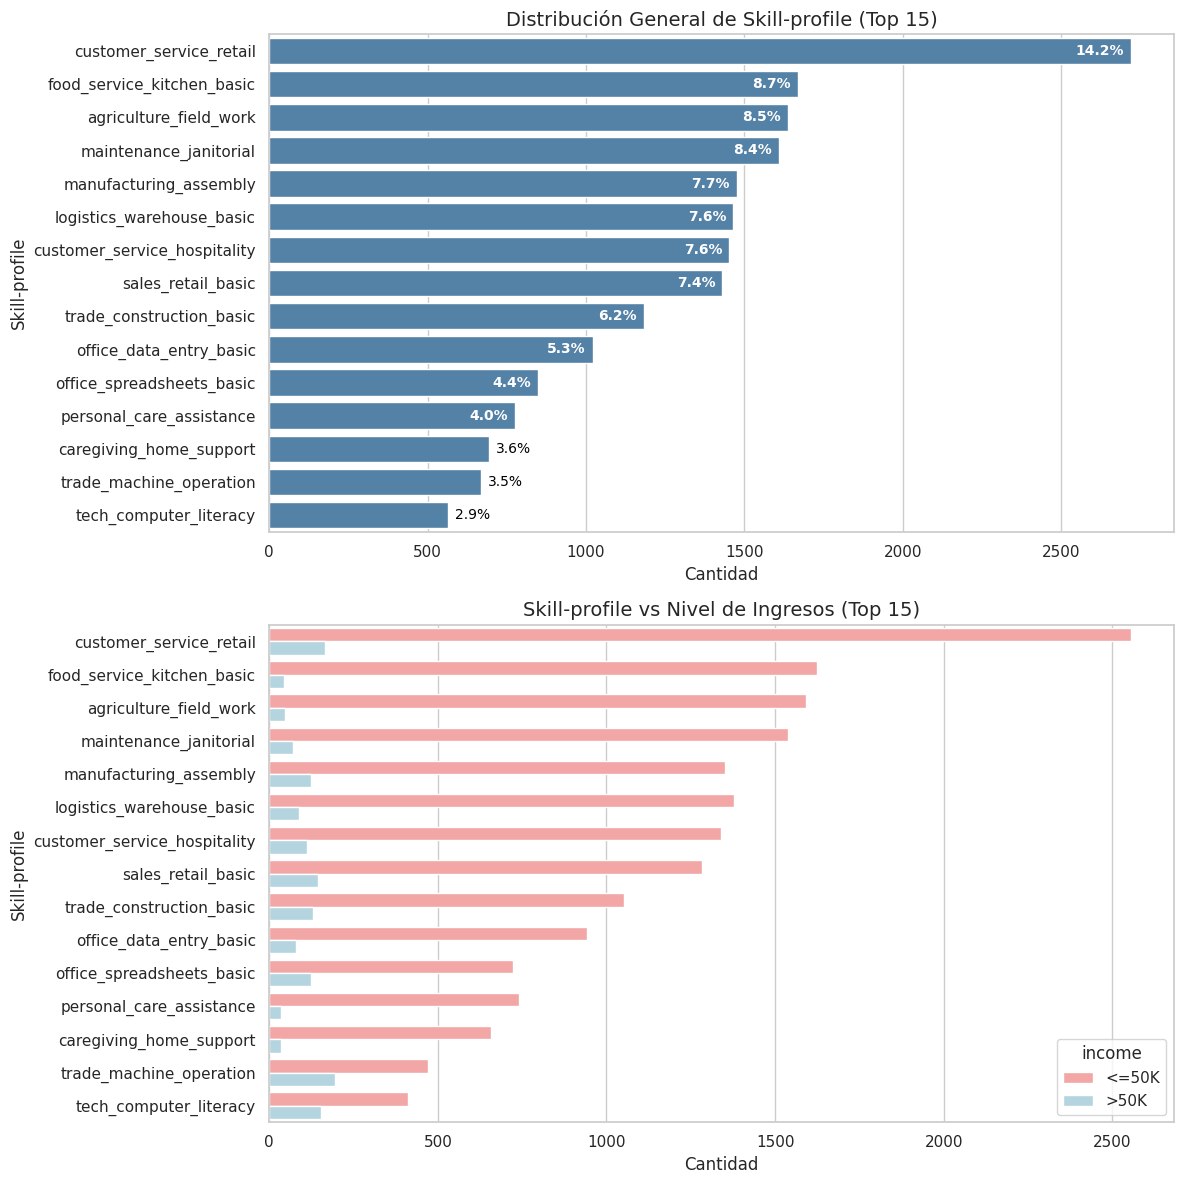

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analizar cardinalidad
cardinalidad_skill = train['skill-profile'].nunique()
conteo_skill = train['skill-profile'].value_counts()

print(f"La cardinalidad de 'skill-profile' es: {cardinalidad_skill}")
print(f"Top 15 valores únicos:\n{conteo_skill.head(15)}\n")

# Quedarnos solo con el Top 15 para la visualización
top_15_skills = conteo_skill.head(15).index
train_top_skills = train[train['skill-profile'].isin(top_15_skills)]

# Configurar la figura
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# 1. Distribución general de Skill-profile (Top 15)
sns.countplot(data=train_top_skills, y='skill-profile', ax=axes[0], order=top_15_skills, color='steelblue')
axes[0].set_title('Distribución General de Skill-profile (Top 15)', fontsize=14)
axes[0].set_xlabel('Cantidad', fontsize=12)
axes[0].set_ylabel('Skill-profile', fontsize=12)

# Agregar porcentajes adentro/junto a las barras
total_records = len(train_top_skills)
for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        percentage = f'{100 * width / total_records:.1f}%'
        if width < (0.04 * total_records):
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points', color='black', fontsize=10)
        else:
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='right', va='center', xytext=(-5, 0), textcoords='offset points', color='white', fontweight='bold', fontsize=10)

# 2. Skill-profile vs Income (Top 15)
sns.countplot(data=train_top_skills, y='skill-profile', hue='income', ax=axes[1], order=top_15_skills, palette=custom_palette)
axes[1].set_title('Skill-profile vs Nivel de Ingresos (Top 15)', fontsize=14)
axes[1].set_xlabel('Cantidad', fontsize=12)
axes[1].set_ylabel('Skill-profile', fontsize=12)

plt.tight_layout()
plt.show()

- Cardinalidad de 80, Embeddings

### Native-country
País de nacimiento del individuo.

La cardinalidad de 'native-country' es: 41
Top 15 valores únicos:
native-country
United-States         27504
Mexico                  610
Philippines             188
Germany                 128
Puerto-Rico             109
Canada                  107
El-Salvador             100
India                   100
Cuba                     92
England                  86
Jamaica                  80
South                    71
Italy                    68
China                    68
Dominican-Republic       67
Name: count, dtype: int64



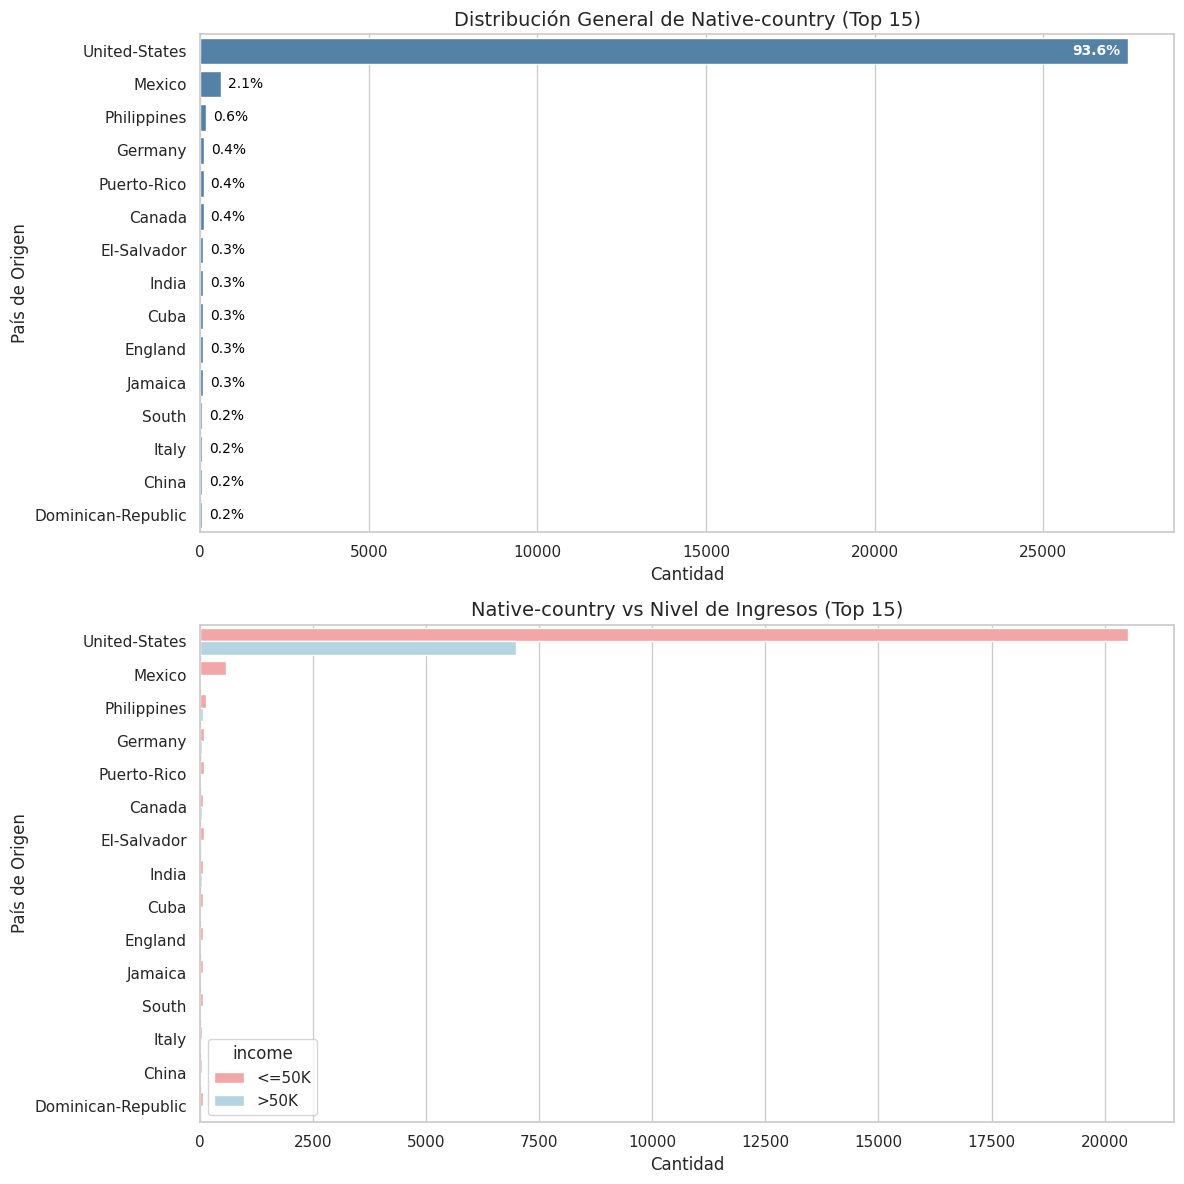

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analizar cardinalidad
cardinalidad_country = train['native-country'].nunique()
conteo_country = train['native-country'].value_counts()

print(f"La cardinalidad de 'native-country' es: {cardinalidad_country}")
print(f"Top 15 valores únicos:\n{conteo_country.head(15)}\n")

# Quedarnos solo con el Top 15 para la visualización
top_15_countries = conteo_country.head(15).index
train_top_countries = train[train['native-country'].isin(top_15_countries)]

# Configurar la figura
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# 1. Distribución general de Native-country (Top 15)
sns.countplot(data=train_top_countries, y='native-country', ax=axes[0], order=top_15_countries, color='steelblue')
axes[0].set_title('Distribución General de Native-country (Top 15)', fontsize=14)
axes[0].set_xlabel('Cantidad', fontsize=12)
axes[0].set_ylabel('País de Origen', fontsize=12)

# Agregar porcentajes adentro/junto a las barras
total_records = len(train_top_countries)
for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        percentage = f'{100 * width / total_records:.1f}%'
        if width < (0.04 * total_records):
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points', color='black', fontsize=10)
        else:
            axes[0].annotate(percentage, (width, p.get_y() + p.get_height() / 2),
                             ha='right', va='center', xytext=(-5, 0), textcoords='offset points', color='white', fontweight='bold', fontsize=10)

# 2. Native-country vs Income (Top 15)
sns.countplot(data=train_top_countries, y='native-country', hue='income', ax=axes[1], order=top_15_countries, palette=custom_palette)
axes[1].set_title('Native-country vs Nivel de Ingresos (Top 15)', fontsize=14)
axes[1].set_xlabel('Cantidad', fontsize=12)
axes[1].set_ylabel('País de Origen', fontsize=12)

plt.tight_layout()
plt.show()

- Cardinalidad de 41, pero casi todos solo en 3 o 4 clases. Pensarlo

### Hours-per-week
Cantidad de horas trabajadas por semana (variable numérica).

Estadísticas descriptivas de la variable 'hours-per-week':


,hours-per-week
count,30162.000000
mean,40.931238
std,11.979984
min,1.000000
25%,40.000000
50%,40.000000
75%,45.000000
max,99.000000


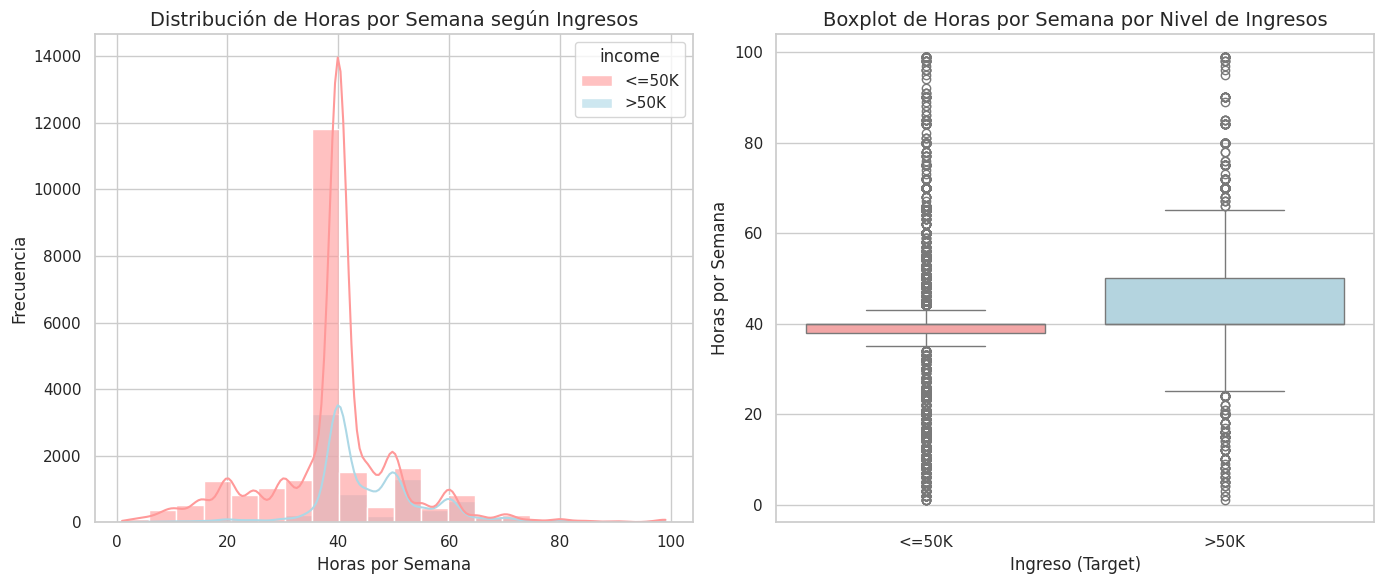

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mostrar estadísticas descriptivas de la variable 'hours-per-week'
print("Estadísticas descriptivas de la variable 'hours-per-week':")
display(train['hours-per-week'].describe())

# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Histograma superpuesto por clase (Income)
sns.histplot(data=train, x='hours-per-week', hue='income', bins=20, kde=True, ax=axes[0], palette=custom_palette, alpha=0.6)
axes[0].set_title('Distribución de Horas por Semana según Ingresos', fontsize=14)
axes[0].set_xlabel('Horas por Semana', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# 2. Boxplot de Horas por Semana por clase (Income)
sns.boxplot(data=train, x='income', y='hours-per-week', hue='income', ax=axes[1], palette=custom_palette, legend=False)
axes[1].set_title('Boxplot de Horas por Semana por Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Ingreso (Target)', fontsize=12)
axes[1].set_ylabel('Horas por Semana', fontsize=12)

plt.tight_layout()
plt.show()

- Poca dispersion
- Pasarla a Ordinal?

### Capital-gain
Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

Estadísticas descriptivas de la variable 'capital-gain':


,capital-gain
count,30162.000000
mean,1092.007858
std,7406.346497
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000



Cantidad de registros con capital-gain igual a 0: 27624
Porcentaje de registros con capital-gain igual a 0: 91.59%



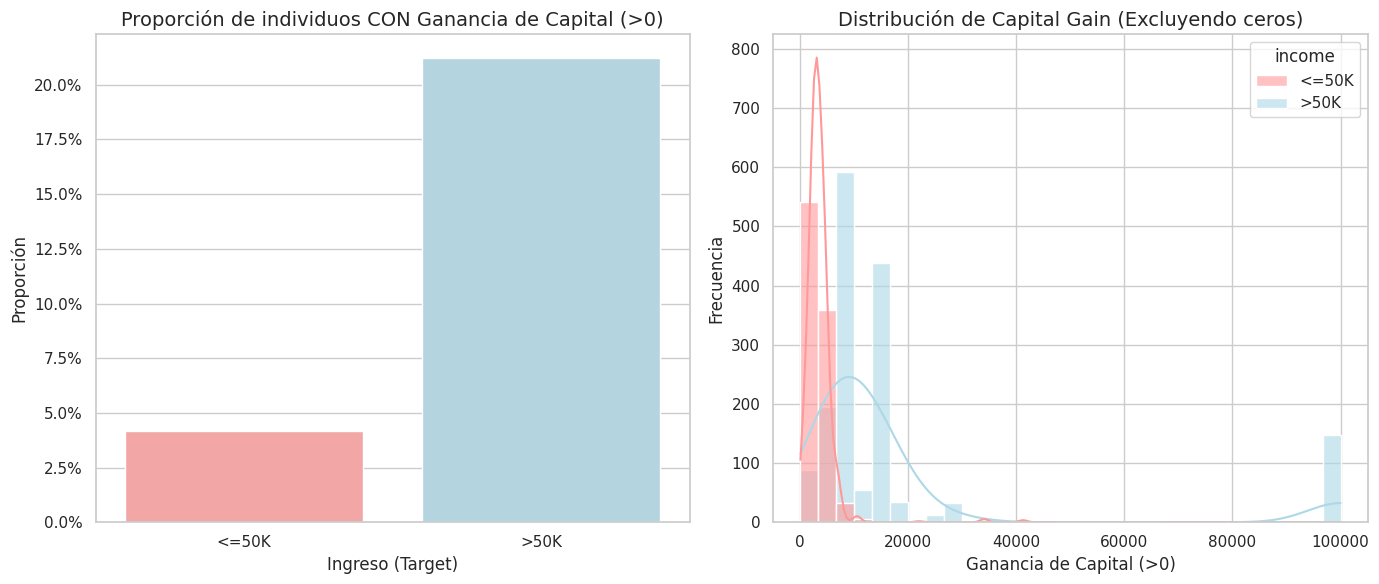

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as mtick

# Chequeo de seguridad por si el kernel se reinició
if 'train' not in globals():
    train = pd.read_csv('dataset/adult_train.csv')
if 'custom_palette' not in globals():
    custom_palette = {'<=50K': '#ff9999', '>50K': '#add8e6'}

# Mostrar estadísticas descriptivas de la variable 'capital-gain'
print("Estadísticas descriptivas de la variable 'capital-gain':")
display(train['capital-gain'].describe())

# Calcular y mostrar cantidad y porcentaje de 0s
zeros_count = (train['capital-gain'] == 0).sum()
total_count = len(train)
zeros_pct = (zeros_count / total_count) * 100

print(f"\nCantidad de registros con capital-gain igual a 0: {zeros_count}")
print(f"Porcentaje de registros con capital-gain igual a 0: {zeros_pct:.2f}%\n")

# --- NUEVA VISUALIZACIÓN MÁS CLARA ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Creamos una variable temporal para ver quién tiene ganancias > 0
train['has_capital_gain'] = train['capital-gain'] > 0

# 1. Gráfico de barras: Proporción de personas con ganancia > 0 según su ingreso
sns.barplot(data=train, x='income', y='has_capital_gain', hue='income', palette=custom_palette, ax=axes[0], errorbar=None, legend=False)
axes[0].set_title('Proporción de individuos CON Ganancia de Capital (>0)', fontsize=14)
axes[0].set_xlabel('Ingreso (Target)', fontsize=12)
axes[0].set_ylabel('Proporción', fontsize=12)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) # Formato porcentaje

# 2. Histograma: Distribución SOLO de los valores mayores a 0
non_zero_gains = train[train['capital-gain'] > 0]
sns.histplot(data=non_zero_gains, x='capital-gain', hue='income', bins=30, kde=True, ax=axes[1], palette=custom_palette, alpha=0.6)
axes[1].set_title('Distribución de Capital Gain (Excluyendo ceros)', fontsize=14)
axes[1].set_xlabel('Ganancia de Capital (>0)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

plt.tight_layout()
plt.show()

# Eliminamos la columna temporal para mantener el dataset original
train = train.drop(columns=['has_capital_gain'])

- **Observaciones sobre Capital-gain:** La inmensa mayoría de los registros tienen valor 0. Los valores altos (outliers positivos) parecen tener una fuerte relación con la clase de ingresos altos (>50K). Al ser numérica y muy sesgada, convendrá aplicar una normalización (como MinMax o RobustScaler) antes de pasarla al modelo.

### Capital-loss
Pérdidas declaradas por capital.

Estadísticas descriptivas de la variable 'capital-loss':


,capital-loss
count,30162.000000
mean,88.372489
std,404.298370
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,4356.000000


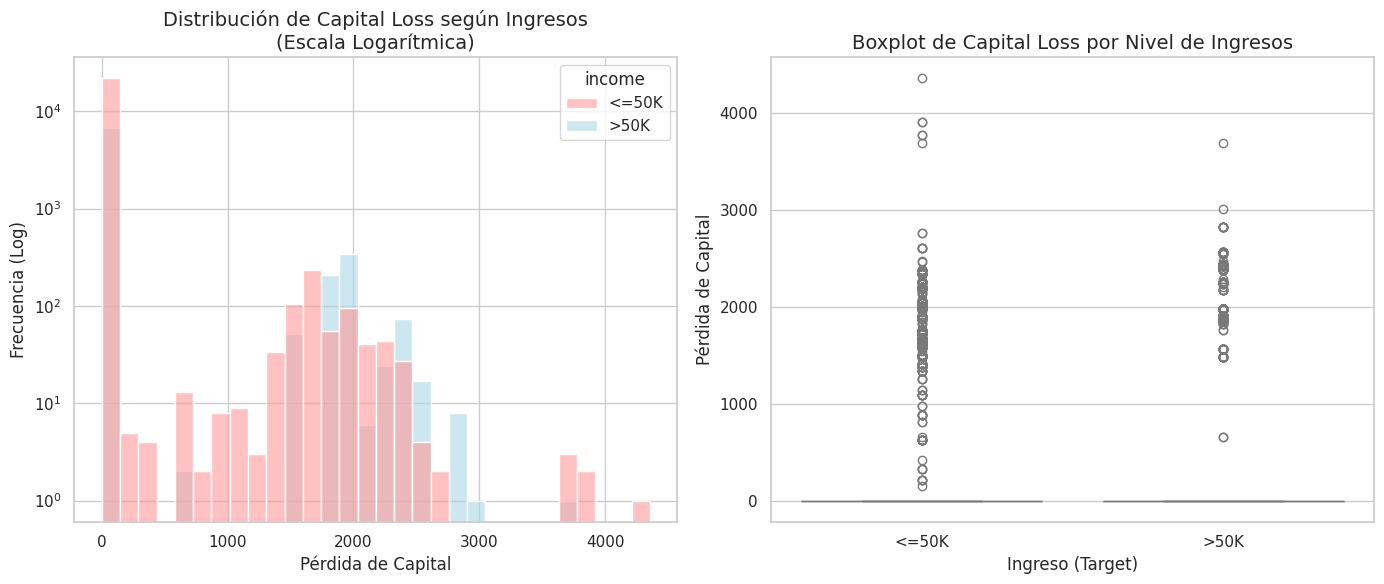

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mostrar estadísticas descriptivas de la variable 'capital-loss'
print("Estadísticas descriptivas de la variable 'capital-loss':")
display(train['capital-loss'].describe())

# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Histograma superpuesto por clase (Income)
sns.histplot(data=train, x='capital-loss', hue='income', bins=30, kde=False, ax=axes[0], palette=custom_palette, alpha=0.6)
axes[0].set_title('Distribución de Capital Loss según Ingresos\n(Escala Logarítmica)', fontsize=14)
axes[0].set_xlabel('Pérdida de Capital', fontsize=12)
axes[0].set_ylabel('Frecuencia (Log)', fontsize=12)
axes[0].set_yscale('log') # Escala logarítmica por el sesgo hacia 0

# 2. Boxplot de Capital Loss por clase (Income)
sns.boxplot(data=train, x='income', y='capital-loss', hue='income', ax=axes[1], palette=custom_palette, legend=False)
axes[1].set_title('Boxplot de Capital Loss por Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Ingreso (Target)', fontsize=12)
axes[1].set_ylabel('Pérdida de Capital', fontsize=12)

plt.tight_layout()
plt.show()

- **Observaciones sobre Capital-loss:** De manera similar a `capital-gain`, la mayoría de los individuos no registran pérdidas de capital (valor 0). Sin embargo, se observan algunos outliers en ambos grupos de ingresos. Al igual que las otras numéricas, será conveniente aplicarle un escalado (como MinMax o RobustScaler) para que el modelo la asimile correctamente.

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.